In [2]:
# Imports
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

print("Bibliotheques importees !")

Bibliotheques importees !


In [3]:
# Creer la base de donnees SQLite
TAUX_USD_FCFA = 600

# Charger le CSV
df = pd.read_csv(
    r'C:\Users\emman\Documents\Portfolio\credit-scoring-deep-learning\data\cs-training.csv'
)
df = df.drop(columns=['Unnamed: 0'])

# Convertir les revenus en FCFA
df['MonthlyIncome_FCFA'] = df['MonthlyIncome'] * TAUX_USD_FCFA

# Creer la connexion SQLite
conn = sqlite3.connect(
    r'C:\Users\emman\Documents\Portfolio\credit-scoring-deep-learning\data\credit_ivoire.db'
)

# Sauvegarder le dataframe dans la base
df.to_sql(
    name='clients',      # nom de la table
    con=conn,            # connexion
    if_exists='replace', # remplacer si existe deja
    index=False          # ne pas sauvegarder l'index
)

print("Base de donnees creee !")
print(f"Table 'clients' : {len(df):,} lignes")

Base de donnees creee !
Table 'clients' : 150,000 lignes


In [4]:
# Fonction utilitaire pour executer une requete SQL
def sql(requete):
    return pd.read_sql_query(requete, conn)

# Requete 1 : Voir les premieres lignes
print("Requete 1 : Les 5 premiers clients")
result = sql("""
    SELECT *
    FROM clients
    LIMIT 5
""")
display(result)

Requete 1 : Les 5 premiers clients


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_FCFA
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,5472000.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,1560000.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,1825200.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,1980000.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,38152800.0


In [5]:
# Requete 2 : Statistiques generales
print("Requete 2 : Statistiques generales")
result = sql("""
    SELECT
        COUNT(*)                    AS total_clients,
        SUM(SeriousDlqin2yrs)      AS total_defauts,
        ROUND(
            AVG(SeriousDlqin2yrs) * 100, 2
        )                           AS taux_defaut_pct,
        ROUND(AVG(age), 1)         AS age_moyen,
        ROUND(
            AVG(MonthlyIncome_FCFA), 0
        )                           AS revenu_moyen_fcfa
    FROM clients
""")
display(result)

Requete 2 : Statistiques generales


,total_clients,total_defauts,taux_defaut_pct,age_moyen,revenu_moyen_fcfa
0,150000,10026,6.68,52.3,4002133.0


In [6]:
# Requete 3 : Comparaison rembourse vs defaut
print("Requete 3 : Profil moyen par statut")
result = sql("""
    SELECT
        CASE SeriousDlqin2yrs
            WHEN 0 THEN 'Rembourse'
            WHEN 1 THEN 'Defaut'
        END                              AS statut,
        COUNT(*)                         AS nombre_clients,
        ROUND(AVG(age), 1)              AS age_moyen,
        ROUND(AVG(MonthlyIncome_FCFA))  AS revenu_moyen_fcfa,
        ROUND(AVG(DebtRatio), 3)        AS ratio_dette_moyen,
        ROUND(AVG(NumberOfDependents))  AS personnes_charge
    FROM clients
    GROUP BY SeriousDlqin2yrs
""")
display(result)

Requete 3 : Profil moyen par statut


,statut,nombre_clients,age_moyen,revenu_moyen_fcfa,ratio_dette_moyen,personnes_charge
0,Rembourse,139974,52.8,4048703.0,357.151,1.0
1,Defaut,10026,45.9,3378496.0,295.121,1.0


In [7]:
# Requete 4 : Taux de defaut par tranche d'age
print("Requete 4 : Taux de defaut par tranche d'age")
result = sql("""
    SELECT
        CASE
            WHEN age < 25  THEN '18-24 ans'
            WHEN age < 35  THEN '25-34 ans'
            WHEN age < 45  THEN '35-44 ans'
            WHEN age < 55  THEN '45-54 ans'
            WHEN age < 65  THEN '55-64 ans'
            ELSE                '65 ans et plus'
        END                              AS tranche_age,
        COUNT(*)                         AS nombre_clients,
        SUM(SeriousDlqin2yrs)           AS nombre_defauts,
        ROUND(
            AVG(SeriousDlqin2yrs) * 100, 2
        )                                AS taux_defaut_pct,
        ROUND(AVG(MonthlyIncome_FCFA))  AS revenu_moyen_fcfa
    FROM clients
    WHERE age > 0
    GROUP BY tranche_age
    ORDER BY taux_defaut_pct DESC
""")
display(result),

Requete 4 : Taux de defaut par tranche d'age


,tranche_age,nombre_clients,nombre_defauts,taux_defaut_pct,revenu_moyen_fcfa
0,25-34 ans,17165,1933,11.26,2572854.0
1,18-24 ans,2074,217,10.46,1037882.0
2,35-44 ans,28563,2585,9.05,3979451.0
3,45-54 ans,36776,2850,7.75,4548510.0
4,55-64 ans,34228,1659,4.85,4571160.0
5,65 ans et plus,31193,782,2.51,3766405.0


(None,)

In [8]:
# Requete 5 : Impact des retards sur le defaut
print("Requete 5 : Impact des retards de paiement")
result = sql("""
    SELECT
        CASE
            WHEN "NumberOfTime30-59DaysPastDueNotWorse" = 0
            AND  "NumberOfTimes90DaysLate" = 0
            THEN 'Aucun retard'
            WHEN "NumberOfTime30-59DaysPastDueNotWorse" > 0
            AND  "NumberOfTimes90DaysLate" = 0
            THEN 'Retards mineurs'
            ELSE 'Retards graves'
        END                          AS profil_retard,
        COUNT(*)                     AS nombre_clients,
        ROUND(
            AVG(SeriousDlqin2yrs) * 100, 2
        )                            AS taux_defaut_pct,
        ROUND(
            AVG(MonthlyIncome_FCFA)
        )                            AS revenu_moyen_fcfa
    FROM clients
    GROUP BY profil_retard
    ORDER BY taux_defaut_pct DESC
""")
display(result)

Requete 5 : Impact des retards de paiement


,profil_retard,nombre_clients,taux_defaut_pct,revenu_moyen_fcfa
0,Retards graves,8338,41.64,3107999.0
1,Retards mineurs,19633,14.45,4095264.0
2,Aucun retard,122029,3.05,4048152.0


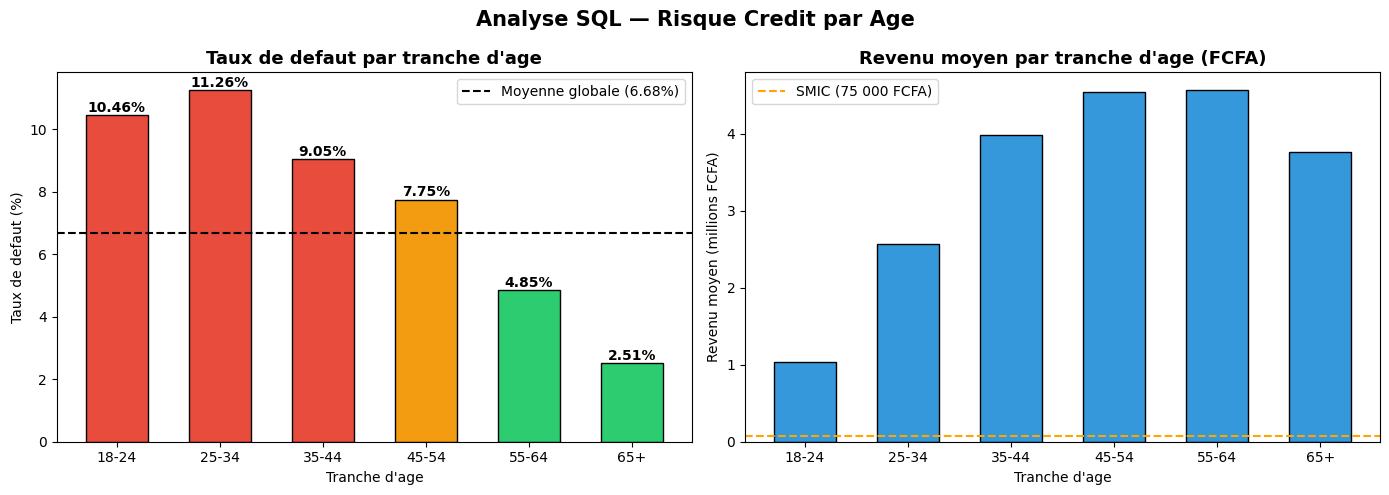

Graphique sauvegarde !


In [10]:
# Visualisation taux de defaut par tranche d'age
result_age = sql("""
    SELECT
        CASE
            WHEN age < 25  THEN '18-24'
            WHEN age < 35  THEN '25-34'
            WHEN age < 45  THEN '35-44'
            WHEN age < 55  THEN '45-54'
            WHEN age < 65  THEN '55-64'
            ELSE                '65+'
        END              AS tranche_age,
        ROUND(
            AVG(SeriousDlqin2yrs) * 100, 2
        )                AS taux_defaut_pct,
        ROUND(
            AVG(MonthlyIncome_FCFA)
        )                AS revenu_moyen_fcfa
    FROM clients
    WHERE age > 0
    GROUP BY tranche_age
    ORDER BY tranche_age
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taux de defaut par age
couleurs = ['#e74c3c' if t > 8
            else '#f39c12' if t > 5
            else '#2ecc71'
            for t in result_age['taux_defaut_pct']]

bars = axes[0].bar(
    result_age['tranche_age'],
    result_age['taux_defaut_pct'],
    color=couleurs,
    edgecolor='black',
    width=0.6
)
axes[0].set_title(
    'Taux de defaut par tranche d\'age',
    fontsize=13, fontweight='bold'
)
axes[0].set_xlabel('Tranche d\'age')
axes[0].set_ylabel('Taux de defaut (%)')
axes[0].axhline(
    y=6.68, color='black',
    linestyle='--', linewidth=1.5,
    label='Moyenne globale (6.68%)'
)
axes[0].legend()
for bar, val in zip(bars, result_age['taux_defaut_pct']):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f'{val}%', ha='center',
        fontweight='bold', fontsize=10
    )

# Revenu moyen par age
axes[1].bar(
    result_age['tranche_age'],
    result_age['revenu_moyen_fcfa'] / 1_000_000,
    color='#3498db', edgecolor='black', width=0.6
)
axes[1].set_title(
    'Revenu moyen par tranche d\'age (FCFA)',
    fontsize=13, fontweight='bold'
)
axes[1].set_xlabel('Tranche d\'age')
axes[1].set_ylabel('Revenu moyen (millions FCFA)')
axes[1].axhline(
    y=75_000/1_000_000,
    color='orange', linestyle='--',
    linewidth=1.5, label='SMIC (75 000 FCFA)'
)
axes[1].legend()

plt.suptitle(
    'Analyse SQL — Risque Credit par Age',
    fontsize=15, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    '../reports/05_sql_analyse_age.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Graphique sauvegarde !")